# BLOQUE 01 – EQUIPAMIENTOS 
## Objetivo
Construir capa consolidada EQUIPAMIENTOS normalizada por unidad espacial.
## Inputs
- equipamientos.shp
- manzana.shp

## Procesos
- Limpieza
- Homologación de CRS
- Join espacial
- Normalización

## Output

1_D3C2_output_1_Equipamientos.gpkg
- 1_D3C2V1_equipamientos.shp
- 1_D3C2V1_Mzn_equipamientos.shp

In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
from dbfread import DBF
import jenkspy
import json
from jenkspy import jenks_breaks
import time

In [5]:
# Rutas
eq_ruta       = r"C:\Users\alflo\Desktop\DAL_LAB\data_raw\Equipamientos\14sip.shp"
manzanas_ruta = r"C:\Users\alflo\Desktop\DAL_LAB\data_raw\Manzanas\14m.shp"

Diccionario_comentado = r"C:\Users\alflo\Desktop\DAL_LAB\data_raw\Equipamientos\Diccionario_pond_2020.xlsx"
Diccionario_nuevo = r"C:\Users\alflo\Desktop\DAL_LAB\data_raw\Equipamientos\Diccionario_2026.xlsx"
Diccionario_actualizado = r"C:\Users\alflo\Desktop\DAL_LAB\data_raw\Equipamientos\Diccionario_pond_2026.xlsx"

ruta_salida   = r"C:\Users\alflo\Desktop\DAL_LAB\outputs\etapa_1\1_D3C2_Equipamientos.gpkg"

In [6]:
# Cargar los GeoDataFrames
gdf_eq = gpd.read_file(eq_ruta)
gdf_manzanas = gpd.read_file(manzanas_ruta)

In [7]:
gdf_eq = gdf_eq.to_crs(gdf_manzanas.crs)

In [8]:
gdf_eq.columns

Index(['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_LOC', 'CVE_AGEB', 'CVE_MZA',
       'CONDICION', 'GEOGRAFICO', 'NOMSERV', 'TIPO', 'CVE_SERV', 'AMBITO',
       'geometry'],
      dtype='object')

In [9]:
gdf_eq = gdf_eq.drop(columns=['CVE_SERV', 'AMBITO'])

## Actualización del diccionario

In [10]:
# carga de diccionario viejo
diccionario = pd.read_excel(Diccionario_comentado)

#crear nuevo dic

# Agrupar por 'GEOGRÁFICO' y obtener los valores únicos de 'TIPO' para cada uno
diccionario_geografico_tipo = {}

# Recorrer cada valor único de GEOGRAFICO
for geografico in gdf_eq['GEOGRAFICO'].unique():
    # Filtrar los datos correspondientes al valor de 'GEOGRAFICO' actual
    subset = gdf_eq[gdf_eq['GEOGRAFICO'] == geografico]
    
    # Obtener los valores únicos de 'TIPO' asociados a este 'GEOGRAFICO'
    tipos = subset['TIPO'].unique()
    
    # Añadir al diccionario, si no tiene subniveles, ponemos una lista vacía
    diccionario_geografico_tipo[geografico] = list(tipos) if len(tipos) > 0 else []

# Mostrar el diccionario creado
for geo, tipos in diccionario_geografico_tipo.items():
    print(f"{geo}: {tipos}")

# Convertir el diccionario en un DataFrame
data = []

# Recorrer el diccionario y estructurarlo en filas
for geografico, tipos in diccionario_geografico_tipo.items():
    if tipos:  # Si hay subniveles en 'TIPO'
        for tipo in tipos:
            data.append([geografico, tipo])
    else:
        data.append([geografico, None])  # Si no hay subniveles, ponemos 'None' en 'TIPO'

Plaza: ['No Aplica']
Escuela: ['Media Superior', 'Secundaria', 'Primaria', 'Preescolar', 'Mixto', 'Superior']
Templo: ['No Aplica']
Centro de Asistencia Médica: ['Centro de Salud', 'Hospital', 'Centro de Rehabilitación']
Instalación Deportiva o Recreativa: ['Cancha', 'Unidad Deportiva', 'Lienzo Charro', 'Parque', 'Plaza de Toros', 'Balneario', 'Jardín', 'Campo de Golf', 'Estadio', 'Áreas Verdes', 'Velódromo', 'Acuario', 'Zoológico', 'Campo de Tiro', 'Hipódromo']
Pozo: ['Agua']
Tanque de Agua: ['Tanque Elevado', 'Caja de Agua']
Cementerio: ['No Aplica']
Instalación Gubernamental: ['Palacio Municipal', 'Palacio de Gobierno']
Mercado: ['No Aplica']
Instalación de Servicios: ['Centro de Asistencia Social', 'Central de Bomberos', 'Central de Policía']
Instalación Diversa: ['Silo', 'Edificación Cultural', 'Museo', 'Centro de Espectáculos', 'Reclusorio', 'Monumento u Obelisco', 'Centro de Investigación', 'Planta de Tratamiento de Agua', 'Teatro', 'Estación de Gas']
Instalación de Comunicación

In [11]:
# Crear DataFrame
df_diccionario = pd.DataFrame(data, columns=['GEOGRAFICO', 'TIPO'])

In [12]:
# Unir el diccionario nuevo con el viejo (asegurarse de que haya un campo en común 'GEOGRAFICO' y 'TIPO')
df_diccionario = df_diccionario.merge(diccionario, on=['GEOGRAFICO', 'TIPO'], how='left')

In [13]:
# Exportar a archivo Excel
df_diccionario.to_excel(Diccionario_nuevo, index=False)

print(f"Diccionario exportado exitosamente a {Diccionario_nuevo}")

Diccionario exportado exitosamente a C:\Users\alflo\Desktop\DAL_LAB\data_raw\Equipamientos\Diccionario_2026.xlsx


## Unir claves a equipamientos

In [14]:
diccionario = pd.read_excel(Diccionario_actualizado)

# Unir el diccionario con el geodataframe gdf_2020 (asegurarse de que haya un campo en común, por ejemplo 'GEOGRAFICO' y 'TIPO')
gdf_eq = gdf_eq.merge(diccionario, on=['GEOGRAFICO', 'TIPO'], how='left')

In [15]:
gdf_eq.columns

Index(['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_LOC', 'CVE_AGEB', 'CVE_MZA',
       'CONDICION', 'GEOGRAFICO', 'NOMSERV', 'TIPO', 'geometry', '#',
       'CATEGORIA', 'RADIO', 'IMP'],
      dtype='object')

In [16]:
gdf_eq = gdf_eq.drop(columns=['#'])

In [17]:
gdf_eq.to_file(ruta_salida, layer=f"1_D3C2V1_equipamientos.shp", driver="GPKG")

In [18]:
conteo_combinaciones = (
    gdf_eq['CATEGORIA']
    .value_counts()
    .reset_index()
)

conteo_combinaciones.columns = ['CATEGORIA', 'frecuencia']
conteo_combinaciones

,CATEGORIA,frecuencia
0,Educación,7263
1,Recreación,3762
2,Cultura,3244
3,Comercio,1709
4,Salud,1491
5,Agua,790
6,Servicios,730
7,Comunicación,52
8,Transporte,1


In [19]:
# Filtrar por categorías y exportar a archivos individuales

# Crear una lista de categorías
categorias = ['Educación', 'Salud', 'Recreación', 'Servicios', 'Comercio', 'Cultura']

# Crear y exportar un GeoDataFrame por cada categoría a una capa dentro del geopackage
for categoria in categorias:
    # Filtrar los equipamientos de la categoría actual
    gdf_categoria = gdf_eq[gdf_eq['CATEGORIA'] == categoria]
    
    # Exportar la categoría como una nueva capa en el geopackage
    gdf_categoria.to_file(ruta_salida, layer=f"1_D3C2V1_equipamientos_{categoria}.shp", driver="GPKG")
    
    print(f"Exportado: {categoria} a la capa {categoria} en el geopackage")

Exportado: Educación a la capa Educación en el geopackage
Exportado: Salud a la capa Salud en el geopackage
Exportado: Recreación a la capa Recreación en el geopackage
Exportado: Servicios a la capa Servicios en el geopackage
Exportado: Comercio a la capa Comercio en el geopackage
Exportado: Cultura a la capa Cultura en el geopackage


## Tratado Manzanas

In [20]:
#3.1: Cargar el archivo de manzanas

# Cargar el archivo de manzanas
gdf_manzanas = gpd.read_file(manzanas_ruta)

In [21]:
# Crear un buffer de 2 metros alrededor de las manzanas
gdf_manzanas['buffer_2m'] = gdf_manzanas.geometry.buffer(2)

# Establecer el buffer como la geometría activa
gdf_manzanas = gdf_manzanas.set_geometry('buffer_2m')

# Inicializar las columnas para contar equipamientos en cada categoría
gdf_manzanas['num_edu'] = 0
gdf_manzanas['num_sal'] = 0
gdf_manzanas['num_rec'] = 0
gdf_manzanas['num_ser'] = 0
gdf_manzanas['num_com'] = 0
gdf_manzanas['num_cul'] = 0

# Lista de categorías y sus respectivas columnas de conteo
categorias = {
    'Educación': 'num_edu',
    'Salud': 'num_sal',
    'Recreación': 'num_rec',
    'Servicios': 'num_ser',
    'Comercio': 'num_com',
    'Cultura': 'num_cul'
}

In [22]:
# Cargar cada capa de equipamientos desde el geopackage y contar los elementos por manzana
for categoria, columna_conteo in categorias.items():
    # Cargar la capa correspondiente desde el geopackage
    gdf_categoria = gpd.read_file(ruta_salida, layer=f"1_D3C2V1_equipamientos_{categoria}.shp")
    
    # Realizar un join espacial entre los buffers de manzanas y los equipamientos de la categoría
    joined = gpd.sjoin(gdf_manzanas[['buffer_2m']], gdf_categoria, how='left', predicate='contains')
    
    # Contar los equipamientos de la categoría por cada manzana
    gdf_manzanas[columna_conteo] = joined.groupby(joined.index)['index_right'].count()

    print(f"Conteo completado para la categoría: {categoria}")

#borrar columna del buffer
gdf_manzanas = gdf_manzanas.drop(columns=['buffer_2m'])

# Establecer el buffer como la geometría activa
gdf_manzanas = gdf_manzanas.set_geometry('geometry')

Conteo completado para la categoría: Educación
Conteo completado para la categoría: Salud
Conteo completado para la categoría: Recreación
Conteo completado para la categoría: Servicios
Conteo completado para la categoría: Comercio
Conteo completado para la categoría: Cultura


In [23]:
#Guardar la capa resultante en un archivo .gpkg
gdf_manzanas.to_file(ruta_salida, layer='1_D3C2V1_equipamientos_mzn', driver="GPKG")

## Cálculo importancia

In [24]:
gdf_manzanas = gpd.read_file(ruta_salida, layer="1_D3C2V1_equipamientos_mzn")

In [25]:
def sumar_importancia(manzanas, puntos, categoria):

    # asegurar CRS igual
    if puntos.crs != manzanas.crs:
        puntos = puntos.to_crs(manzanas.crs)

    buffer_map = {1:400, 2:2400, 3:9600}

    puntos = puntos.copy()
    puntos["RADIO_M"] = puntos["RADIO"].map(buffer_map)

    buffers = puntos.copy()
    buffers["geometry"] = buffers.buffer(buffers["RADIO_M"])

    # spatial join
    join = gpd.sjoin(
        manzanas[["CVEGEO","geometry"]],
        buffers[["IMP","geometry"]],
        predicate="intersects",
        how="left"
    )

    # sumar importancia por manzana
    suma = (
        join.groupby("CVEGEO")["IMP"]
        .sum()
        .reset_index()
        .rename(columns={"IMP":f"IMP_{categoria}"})
    )

    # unir a manzanas
    manzanas = manzanas.merge(suma, on="CVEGEO", how="left")

    manzanas[f"IMP_{categoria}"] = manzanas[f"IMP_{categoria}"].fillna(0)

    print(f"Categoría procesada: {categoria}")

    return manzanas

In [26]:
ruta_buffers = {
    "EDU": "Educación",
    "SAL": "Salud",
    "REC": "Recreación",
    "SER": "Servicios",
    'COM': 'Comercio',
    'CUL': 'Cultura'
}

for categoria, nombre in ruta_buffers.items():

    gdf_eq = gpd.read_file(ruta_salida, layer=f"1_D3C2V1_equipamientos_{nombre}.shp")

    gdf_manzanas = sumar_importancia(gdf_manzanas, gdf_eq, categoria)

Categoría procesada: EDU
Categoría procesada: SAL
Categoría procesada: REC
Categoría procesada: SER
Categoría procesada: COM
Categoría procesada: CUL


In [27]:
gdf_manzanas.to_file(ruta_salida, layer="1_D3C2V1_equipamientos_mzn.shp", driver="GPKG")

In [28]:
### Comprobación 

In [29]:
cols_imp = [c for c in gdf_manzanas.columns if c.startswith("IMP_")]
print(cols_imp)

['IMP_EDU', 'IMP_SAL', 'IMP_REC', 'IMP_SER', 'IMP_COM', 'IMP_CUL']


In [30]:
import pandas as pd

resumen = pd.DataFrame({
    "min": gdf_manzanas[cols_imp].min(),
    "mean": gdf_manzanas[cols_imp].mean(),
    "median": gdf_manzanas[cols_imp].median(),
    "max": gdf_manzanas[cols_imp].max(),
    "sum": gdf_manzanas[cols_imp].sum(),
    "non_zero": (gdf_manzanas[cols_imp] > 0).sum()
})

print(resumen)

         min         mean  median      max          sum  non_zero
IMP_EDU  0.0  6661.244716  1900.0  36860.0  939262150.0    139359
IMP_SAL  0.0    49.956959    27.5    483.0    7044131.0    135773
IMP_REC  0.0   112.265659    61.0   1085.5   15829907.0    136768
IMP_SER  0.0    76.885205    48.0    307.0   10841121.5    136269
IMP_COM  0.0   193.819693    76.0   1936.0   27329352.0    125602
IMP_CUL  0.0     2.589260     1.0     20.0     365096.0    109435


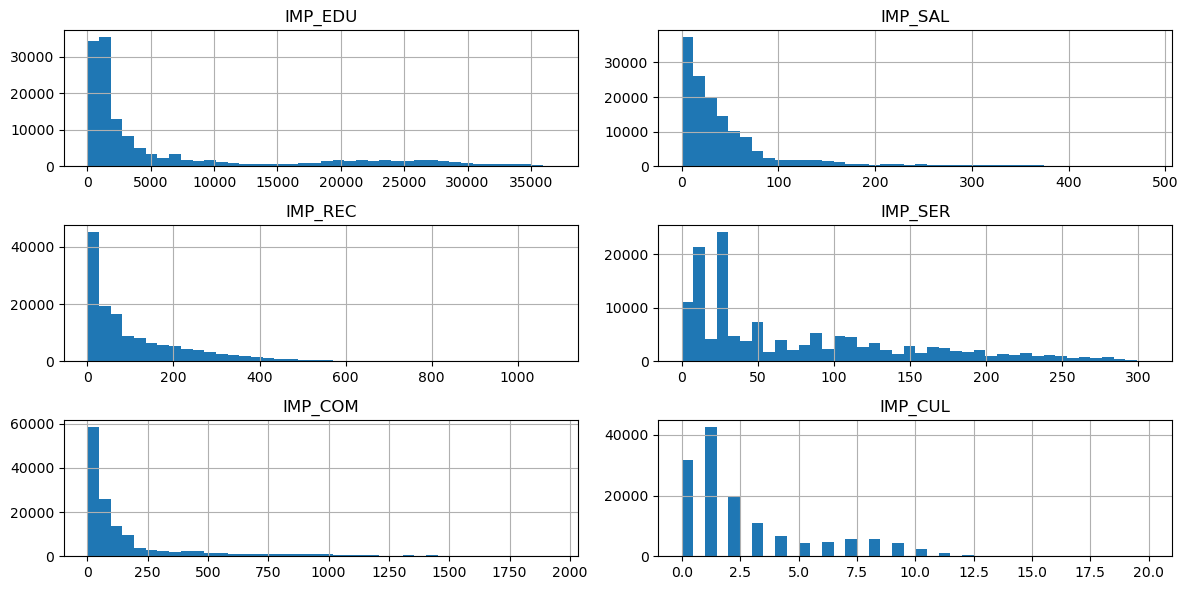

In [31]:
import matplotlib.pyplot as plt

gdf_manzanas[cols_imp].hist(bins=40, figsize=(12,6))
plt.tight_layout()
plt.show()

<Axes: >

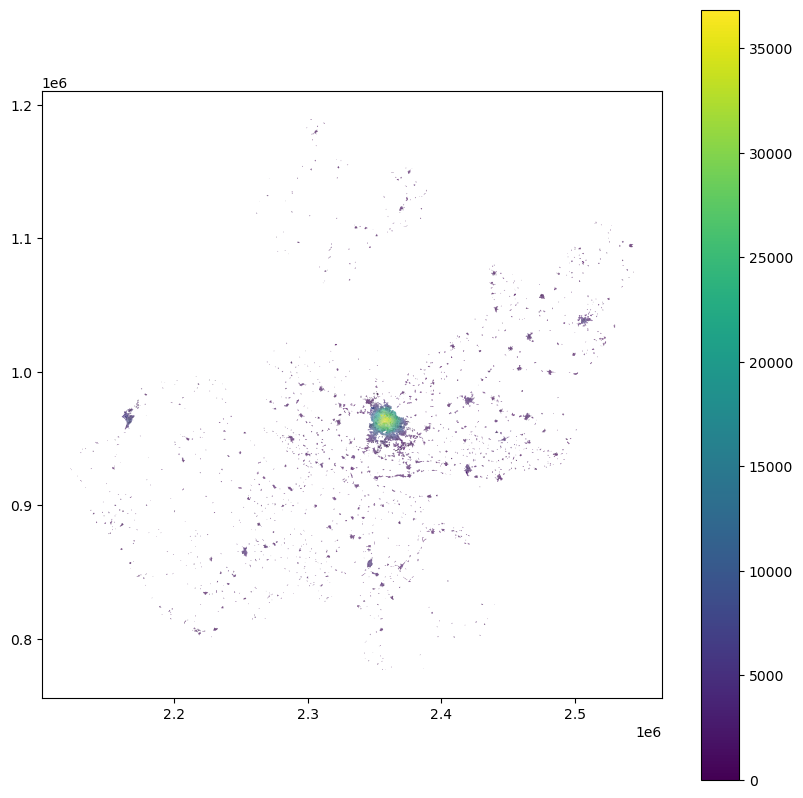

In [32]:
gdf_manzanas.plot(
    column="IMP_EDU",
    cmap="viridis",
    legend=True,
    figsize=(10,10)
)